# Ising model II: critical temperature and optimization

**PHY4008 · Computational Physics II**

Continue from [Ising model I](https://yw-choi.github.io/PHY4008/notebooks/02_ising_model_1.html).
Start with the same spin array and improve one part of the calculation at a time.

Learning goals:

1. Replace full-energy trial calculations with a checked local update.
2. Measure equilibrium properties and compare lattice sizes.
3. Estimate the critical temperature from finite-size curves.
4. Use simulated annealing to search for low-energy configurations.

Required packages: **NumPy, Matplotlib, and Numba**. Run the cells in order.
Numba compiles the explicit loops shown below; the physics is written in ordinary Python.
Place the [saved temperature scan](03_ising_model_2_data.npz) beside this notebook to reuse it.
Without that file, the notebook computes the scan itself, which takes several minutes.

## 0. Setup

Use a periodic square lattice, zero external field, and reduced units $J=k_{\mathrm{B}}=1$.
Each spin is $+1$ or $-1$; the number of spins is $N=L^2$. Use $L\ge3$.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from time import perf_counter

plt.rcParams.update({"font.family": "serif", "font.size": 12,
                     "xtick.direction": "out", "ytick.direction": "out"})
np.set_printoptions(precision=4, suppress=True)

In [2]:
spins = np.array([[1, 1, -1, -1],
                  [1, 1, -1, -1],
                  [1, 1, -1, -1],
                  [1, 1, -1, -1]])
spins

array([[ 1,  1, -1, -1],
       [ 1,  1, -1, -1],
       [ 1,  1, -1, -1],
       [ 1,  1, -1, -1]])

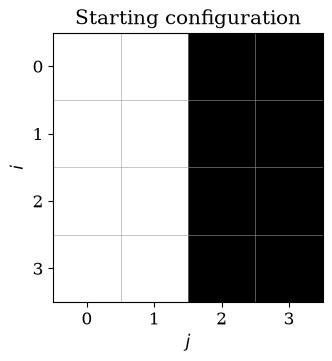

In [3]:
def show_spins(spins):
    L = len(spins)
    plt.imshow(spins, cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
    plt.xticks(range(0, L, max(1, L // 8)))
    plt.yticks(range(0, L, max(1, L // 8)))
    plt.xticks(np.arange(-0.5, L, 1), minor=True)
    plt.yticks(np.arange(-0.5, L, 1), minor=True)
    plt.grid(which="minor", color="#999999", linewidth=0.4)
    plt.tick_params(which="minor", length=0)
    plt.xlabel(r"$j$")
    plt.ylabel(r"$i$")

plt.figure(figsize=(3.5, 3.5))
show_spins(spins)
plt.title("Starting configuration")
plt.show()

## 1. Keep a reference calculation

As before, count each bond once by summing the right and down neighbors.
Keep this function to check a proposed local update.

In [4]:
def total_energy(spins):
    L = len(spins)
    energy = 0
    for i in range(L):
        for j in range(L):
            energy -= spins[i, j] * spins[i, (j + 1) % L]
            energy -= spins[i, j] * spins[(i + 1) % L, j]
    return energy

Pass the proposed site and random number into the reference step.
This lets us give two implementations **exactly the same proposals**.
The reference function preserves its input array.

In [5]:
def flip_reference(spins, T, i, j, u):
    trial = spins.copy()
    trial[i, j] *= -1
    change = total_energy(trial) - total_energy(spins)
    if change <= 0 or u < np.exp(-change / T):
        return trial, True
    return spins, False

## 2. Calculate only what changes

When one spin flips, only its four incident bonds change:

$$\Delta E=2s_{ij}\left(s_{i-1,j}+s_{i+1,j}+s_{i,j-1}+s_{i,j+1}\right).$$

The modulo operation wraps each neighbor index at the boundary.

In [6]:
def delta_energy(spins, i, j):
    L = len(spins)
    neighbors = (spins[(i - 1) % L, j] + spins[(i + 1) % L, j]
                 + spins[i, (j - 1) % L] + spins[i, (j + 1) % L])
    return 2 * spins[i, j] * neighbors

In [7]:
i, j = 0, 0
trial = spins.copy()
trial[i, j] *= -1
print("Full-energy difference:", total_energy(trial) - total_energy(spins))
print("Local difference:", delta_energy(spins, i, j))
assert delta_energy(spins, i, j) == total_energy(trial) - total_energy(spins)

Full-energy difference: 4
Local difference: 4


Check all sites in several random configurations, including the boundaries.

In [8]:
rng = np.random.default_rng(7)
for L in [3, 4, 8]:
    state = rng.choice([-1, 1], size=(L, L))
    for i in range(L):
        for j in range(L):
            trial = state.copy()
            trial[i, j] *= -1
            assert delta_energy(state, i, j) == total_energy(trial) - total_energy(state)
print("Every tested local change agrees with the full-energy difference.")

Every tested local change agrees with the full-energy difference.


Decide whether to accept before constructing a trial array.
Change only the accepted spin. **This function changes its input in place.**
Copy the initial configuration once at the start of each experiment.

In [9]:
def flip_local(spins, T, i, j, u):
    change = delta_energy(spins, i, j)
    if change <= 0 or u < np.exp(-change / T):
        spins[i, j] *= -1
        return True
    return False

### Replay the same proposals

Both implementations receive one site and one uniform random number per attempt,
including attempts whose energy change is nonpositive.

In [10]:
def replay(initial, T, sites, uniforms, local):
    spins = initial.copy()
    for k in range(len(uniforms)):
        i, j = sites[k]
        if local:
            flip_local(spins, T, i, j, uniforms[k])
        else:
            spins, _ = flip_reference(spins, T, i, j, uniforms[k])
    return spins

In [11]:
rng = np.random.default_rng(21)
initial = rng.choice([-1, 1], size=(8, 8))
sites = rng.integers(0, 8, size=(500, 2))
uniforms = rng.random(500)
reference = replay(initial, 2.3, sites, uniforms, local=False)
local = replay(initial, 2.3, sites, uniforms, local=True)
assert np.array_equal(reference, local)
print("Same proposals, same final configuration.")

Same proposals, same final configuration.


## 3. Measure the speed

Time two sweeps for each lattice size, excluding proposal generation and plotting.
Report the median of three repetitions. Both versions perform the same work.

The reference step visits the full array and copies it at every attempt.
Removing both operations changes the main work per sweep from
$O(N^2)=O(L^4)$ to $O(N)=O(L^2)$.

In [12]:
benchmark = []
for L in [8, 16, 32]:
    rng = np.random.default_rng(30 + L)
    initial = rng.choice([-1, 1], size=(L, L))
    sites = rng.integers(0, L, size=(2 * L * L, 2))
    uniforms = rng.random(len(sites))
    times = []
    for local in [False, True]:
        repeats = []
        for _ in range(3):
            start = perf_counter()
            replay(initial, 2.3, sites, uniforms, local)
            repeats.append(perf_counter() - start)
        times.append(np.median(repeats))
    benchmark.append([L, *times])
    print(f"L={L:2d}: reference {times[0]:.4f} s, local {times[1]:.4f} s, "
          f"speedup {times[0] / times[1]:.1f}")

L= 8: reference 0.0043 s, local 0.0002 s, speedup 24.1


L=16: reference 0.0684 s, local 0.0007 s, speedup 101.4

L=32: reference 1.0068 s, local 0.0027 s, speedup 377.7


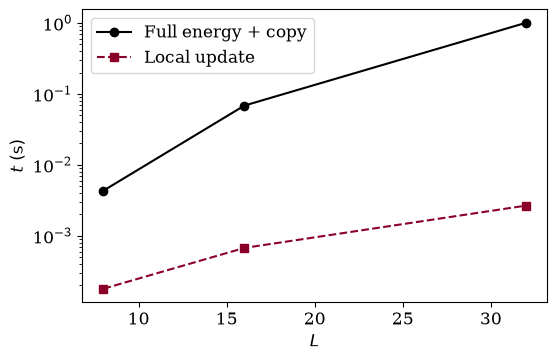

In [13]:
benchmark = np.array(benchmark)
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(benchmark[:, 0], benchmark[:, 1], "o-", color="black", label="Full energy + copy")
ax.plot(benchmark[:, 0], benchmark[:, 2], "s--", color="#8B0029", label="Local update")
ax.set(xlabel=r"$L$", ylabel=r"$t\ (\mathrm{s})$", yscale="log")
ax.legend()
plt.show()

**Observe:** the speedup depends on lattice size and the machine.
Removing repeated work helps while the explicit loops remain readable.

## 4. Sweeps, measurements, and compilation

One sweep is $N$ randomly selected attempts. A site may be selected more than once.
Draw the generator once and pass it to the function.

In [14]:
def sweep(spins, T, rng):
    L = len(spins)
    for _ in range(spins.size):
        i, j = rng.integers(0, L), rng.integers(0, L)
        u = rng.random()
        flip_local(spins, T, i, j, u)

Discard an initial equilibration interval, then record total energy and total magnetization.
The parameter <code>stride</code> is the number of sweeps between measurements.
It does not guarantee independence. Rejections keep the state and still count as attempts.

In [15]:
def run(initial, T, n_equil, n_samples, rng, stride=1):
    if T <= 0:
        raise ValueError("T must be positive.")
    spins = initial.copy()
    for _ in range(n_equil):
        sweep(spins, T, rng)
    energies = np.empty(n_samples)
    magnetizations = np.empty(n_samples)
    for k in range(n_samples):
        for _ in range(stride):
            sweep(spins, T, rng)
        energies[k] = total_energy(spins)
        magnetizations[k] = spins.sum()
    return spins, energies, magnetizations

First run ordinary Python. Then compile **the same functions** with Numba.
Compare the sampled trajectories before and after compilation.

In [16]:
initial = np.ones((8, 8), dtype=np.int64)
start = perf_counter()
python_result = run(initial, 2.3, 10, 100, np.random.default_rng(42))
python_seconds = perf_counter() - start

In [17]:
from numba import njit

total_energy = njit(total_energy)
delta_energy = njit(delta_energy)
flip_local = njit(flip_local)
sweep = njit(sweep)
run = njit(run)

start = perf_counter()
compiled_result = run(initial, 2.3, 10, 100, np.random.default_rng(42))
first_call_seconds = perf_counter() - start
for before, after in zip(python_result, compiled_result):
    assert np.array_equal(before, after)

In [18]:
warm_times = []
for _ in range(5):
    start = perf_counter()
    run(initial, 2.3, 10, 100, np.random.default_rng(42))
    warm_times.append(perf_counter() - start)
jit_seconds = np.median(warm_times)
print(f"Python: {python_seconds:.4f} s")
print(f"First compiled call (including compilation): {first_call_seconds:.4f} s")
print(f"Warm compiled call: {jit_seconds:.6f} s")
print("Sampled arrays agree exactly for this seeded check.")

Python: 0.0180 s
First compiled call (including compilation): 0.6455 s
Warm compiled call: 0.000353 s
Sampled arrays agree exactly for this seeded check.


Compilation accelerates the loops; it does not reduce the sweeps needed for equilibrium.
The scan below uses these compiled functions. The first call includes compilation overhead.

## 5. When should we start measuring?

**Do not average the initial adjustment into an equilibrium measurement.**
Start from two different configurations at the same temperature: all spins up and random spins.
Here we use $T=3.0$, above the transition, so the initial relaxation is easier to see
than near the critical temperature. The temperature scan later in the notebook is a separate calculation.

First inspect the first 100 sweeps, including the initial configuration at sweep zero.
The shaded interval marks a **trial discard of 50 sweeps**, not an automatically detected equilibration time.
Then compare a late-time window. Equilibrium means a stationary distribution, not a flat trace
or two trajectories that coincide point by point.

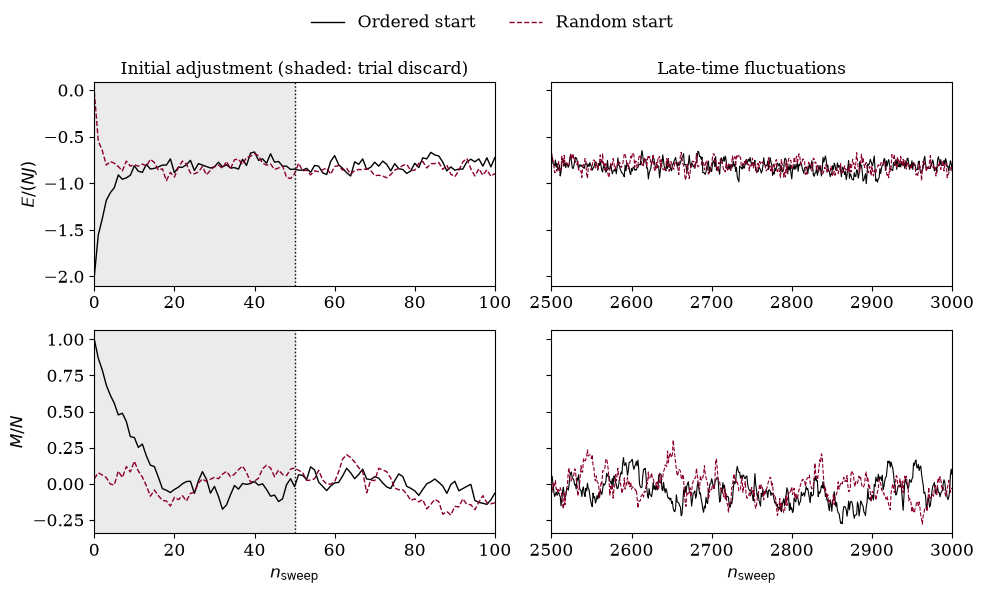

In [19]:
L, T = 32, 3.0
n_steps, discard = 3000, 50
rng = np.random.default_rng(50)
starts = [np.ones((L, L), dtype=np.int64),
          rng.choice([-1, 1], size=(L, L))]
relaxation = [run(state, T, 0, n_steps, np.random.default_rng(60 + k))
              for k, state in enumerate(starts)]
labels = ["Ordered start", "Random start"]
colors = ["black", "#8B0029"]
styles = ["-", "--"]

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharey="row")
for state, result, label, color, style in zip(starts, relaxation, labels, colors, styles):
    _, E, M = result
    # run() records AFTER each sweep; prepend the actual initial values.
    e = np.r_[total_energy(state), E] / L**2
    m = np.r_[state.sum(), M] / L**2
    for row, values in enumerate([e, m]):
        axes[row, 0].plot(np.arange(101), values[:101], style,
                          color=color, linewidth=1, label=label)
        axes[row, 1].plot(np.arange(2500, 3001), values[2500:3001], style,
                          color=color, linewidth=0.8)
for row in range(2):
    axes[row, 0].axvspan(0, discard, color="black", alpha=0.08)
    axes[row, 0].axvline(discard, color="black", linestyle=":", linewidth=1)
    axes[row, 0].set_xlim(0, 100)
    axes[row, 1].set_xlim(2500, 3000)
axes[0, 0].set_title("Initial adjustment (shaded: trial discard)", fontsize=12)
axes[0, 1].set_title("Late-time fluctuations", fontsize=12)
axes[0, 0].set_ylabel(r"$E/(NJ)$")
axes[1, 0].set_ylabel(r"$M/N$")
for ax in axes[1]:
    ax.set_xlabel(r"$n_{\mathrm{sweep}}$")
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper center",
           ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

**Read the figure:** the ordered start loses its initial magnetization, while the
energy approaches the same fluctuating range from two different starting values.
The late-time traces still fluctuate; those fluctuations are part of equilibrium.
The two columns use the same vertical scales for each observable.

**Check the proposed measurement start.** Discard more of each trajectory and
recompute the averages using all remaining sweeps up to sweep 3000.
The short initial window is printed separately so its bias is not hidden by a long average.

In [20]:
print("Initial window: sweeps 1-10 (not an equilibrium estimate)")
print(f"{'Start':<16} {'mean E/(NJ)':>14} {'mean M/N':>14}")
for (_, E, M), label in zip(relaxation, labels):
    print(f"{label:<16} {E[:10].mean()/L**2:14.4f} {M[:10].mean()/L**2:14.4f}")

print("\nDiscard check: retain sweeps discard+1 through 3000")
print(f"{'Discard':>7} {'E: ordered':>13} {'E: random':>13}"
      f" {'M: ordered':>13} {'M: random':>13}")
for cut in [0, 25, 50, 100, 200]:
    e_means = [E[cut:].mean()/L**2 for _, E, M in relaxation]
    m_means = [M[cut:].mean()/L**2 for _, E, M in relaxation]
    print(f"{cut:7d} {e_means[0]:13.4f} {e_means[1]:13.4f}"
          f" {m_means[0]:13.4f} {m_means[1]:13.4f}")

Initial window: sweeps 1-10 (not an equilibrium estimate)
Start               mean E/(NJ)       mean M/N
Ordered start           -1.0801         0.5553
Random start            -0.7617         0.0658

Discard check: retain sweeps discard+1 through 3000
Discard    E: ordered     E: random    M: ordered     M: random
      0       -0.8171       -0.8154       -0.0061        0.0022
     25       -0.8162       -0.8155       -0.0083        0.0024
     50       -0.8164       -0.8155       -0.0080        0.0018
    100       -0.8166       -0.8149       -0.0082        0.0024
    200       -0.8172       -0.8144       -0.0066        0.0038


**Discuss:** How different are the first ten sweeps from the retained data?
How much do the means change when the discard increases from 50 to 100 or 200?
For this demonstration, use 50 discarded sweeps as a working choice only after inspecting both checks.
Small changes support that choice for these observables at this temperature; they do not prove equilibration.
The rows reuse overlapping data and are not independent estimates.
If the starts disagree or the averages keep drifting, run longer and repeat the check.
Do not transfer this discard length to another temperature or lattice size without checking again.
Near the transition, relaxation can be much slower. Sampling uncertainty also requires correlated-data analysis.

### From a trace to an observable

For a finite zero-field system, symmetry gives $\langle M\rangle=0$ in equilibrium.
Use $\langle|m|\rangle$ to measure ordering, with $m=M/N$.
Energy fluctuations give the specific heat per spin:

$$c_V=\frac{\langle E^2\rangle-\langle E\rangle^2}{NT^2}.$$

The Binder cumulant uses the shape of the magnetization distribution:

$$U_4=1-\frac{\langle m^4\rangle}{3\langle m^2\rangle^2}.$$

Convert stored integer energies to floating point **before squaring**.

In [21]:
def measure(energies, magnetizations, N, T):
    energies = energies.astype(np.float64)
    m = magnetizations / N
    e = energies.mean() / N
    abs_m = np.abs(m).mean()
    heat = (np.mean(energies**2) - energies.mean()**2) / (N * T**2)
    binder = 1 - np.mean(m**4) / (3 * np.mean(m**2)**2)
    return np.array([e, abs_m, heat, binder])

In [22]:
state, E, M = run(starts[1], 2.3, 4000, 5000, np.random.default_rng(71), stride=5)
print("mean e, mean |m|, specific heat, Binder:")
print(measure(E, M, L * L, 2.3))

mean e, mean |m|, specific heat, Binder:
[-1.3717  0.5488  1.9252  0.5493]


## 6. Temperature and lattice-size effects

Compare $L=8,16,32$ at the same temperatures. Each run starts independently.
Half of the runs start ordered; half start random.
The saved scan discards 8,000 sweeps and records 16,000 samples every five sweeps.
This is 80,000 measured sweeps per run, with four independent runs per point.

Large lattices take longer both because they have more spins and because local updates
can decorrelate slowly near the transition.

In [23]:
def temperature_scan(sizes, temperatures, n_runs, n_equil, n_samples, stride):
    samples = np.empty((len(sizes), len(temperatures), n_runs, 2, n_samples),
                       dtype=np.int16)
    for a, L in enumerate(sizes):
        for b, T in enumerate(temperatures):
            for r in range(n_runs):
                seed = 20260917 + 10000 * int(L) + 100 * b + r
                rng = np.random.default_rng(seed)
                initial = np.ones((L, L), dtype=np.int64)
                if r % 2 == 1:
                    initial = rng.choice(np.array([-1, 1]), size=(L, L))
                _, E, M = run(initial, T, n_equil, n_samples, rng, stride)
                samples[a, b, r, 0] = E
                samples[a, b, r, 1] = M
        print("Finished size", L, flush=True)
    return samples

In [24]:
sizes = np.array([8, 16, 32])
temperatures = np.array([1.5, 2.0, 2.1, 2.15, 2.2, 2.25,
                         2.3, 2.35, 2.4, 2.5, 3.0, 3.5])
parameters = np.array([4, 8000, 16000, 5])  # runs, equilibration, samples, stride
data_path = Path("03_ising_model_2_data.npz")
recompute_scan = False

Use the saved scan only when all its parameters match. Set <code>recompute_scan = True</code>
to generate new data. If the file is missing or parameters change, the calculation runs.
The seed for every run is visible in <code>temperature_scan</code>.

In [25]:
use_saved = False
if data_path.exists() and not recompute_scan:
    with np.load(data_path, allow_pickle=False) as saved:
        use_saved = (saved["schema"].item() == 1
                     and np.array_equal(saved["sizes"], sizes)
                     and np.array_equal(saved["temperatures"], temperatures)
                     and np.array_equal(saved["parameters"], parameters))
        if use_saved:
            samples = saved["samples"]
if not use_saved:
    samples = temperature_scan(sizes, temperatures, *parameters)
    np.savez_compressed(data_path, sizes=sizes, temperatures=temperatures,
                        parameters=parameters, samples=samples, schema=np.array(1))
print("Loaded matching saved samples." if use_saved else "Computed and saved new samples.")
print("Shape (sizes, temperatures, runs, observables, samples):", samples.shape)

Loaded matching saved samples.
Shape (sizes, temperatures, runs, observables, samples): (3, 12, 4, 2, 16000)


Compute one estimate from each independent run. Error bars show the standard error
across those four run estimates. The individual sweep measurements are correlated;
we do not treat all stored samples as independent.

In [26]:
values = np.empty(samples.shape[:3] + (4,))
for a, L in enumerate(sizes):
    for b, T in enumerate(temperatures):
        for r in range(parameters[0]):
            E, M = samples[a, b, r]
            values[a, b, r] = measure(E, M, L * L, T)
means = values.mean(axis=2)
errors = values.std(axis=2, ddof=1) / np.sqrt(parameters[0])

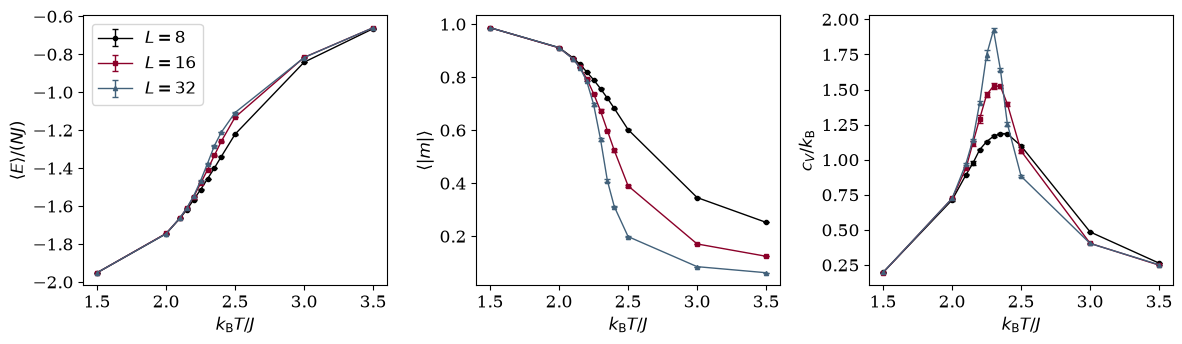

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
labels = [r"$\langle E\rangle/(NJ)$", r"$\langle|m|\rangle$", r"$c_V/k_{\mathrm{B}}$"]
for a, (L, marker, color) in enumerate(zip(sizes, ["o", "s", "^"], ["black", "#8B0029", "#42617A"])):
    for k, ax in enumerate(axes):
        ax.errorbar(temperatures, means[a, :, k], yerr=errors[a, :, k],
                    fmt=marker + "-", color=color, markersize=3, capsize=2,
                    linewidth=1, label=rf"$L={L}$")
for ax, label in zip(axes, labels):
    ax.set(xlabel=r"$k_{\mathrm{B}}T/J$", ylabel=label)
axes[0].legend()
plt.tight_layout()
plt.show()

**Observe:** a finite lattice has rounded curves.
The heat-capacity maximum is a size-dependent temperature, not yet the thermodynamic limit.
Connected points only guide the eye.

In [28]:
print("Size  Temperature of the largest sampled specific heat")
for a, L in enumerate(sizes):
    peak = temperatures[np.argmax(means[a, :, 2])]
    print(f"{L:4d}  {peak:.2f}")

Size  Temperature of the largest sampled specific heat
   8  2.35
  16  2.30
  32  2.30


## 7. Estimate the critical temperature

For a sharply ordered distribution, $U_4$ approaches $2/3$.
For a large disordered system with an approximately Gaussian distribution, it approaches zero.
Near a continuous transition, curves for different sizes cross near $T_c$.
Finite-size corrections can shift those intersections.

Keep the same boundary conditions and square shape when comparing sizes.

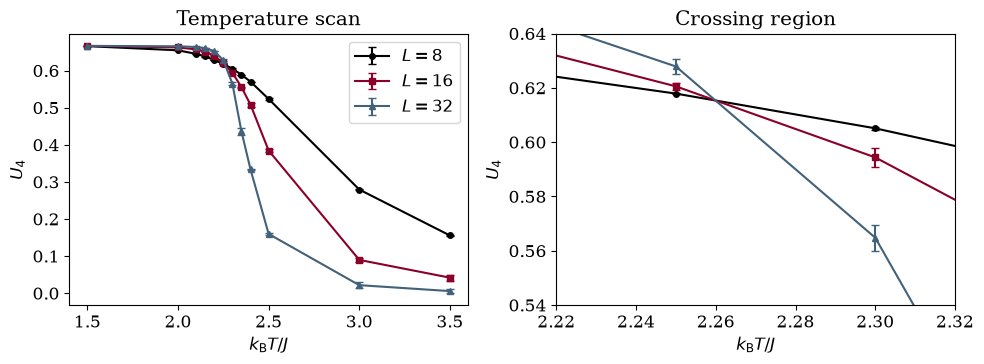

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for a, (L, marker, color) in enumerate(zip(sizes, ["o", "s", "^"], ["black", "#8B0029", "#42617A"])):
    for ax in axes:
        ax.errorbar(temperatures, means[a, :, 3], yerr=errors[a, :, 3],
                    fmt=marker + "-", color=color, markersize=4, capsize=3, label=rf"$L={L}$")
for ax in axes:
    ax.set(xlabel=r"$k_{\mathrm{B}}T/J$", ylabel=r"$U_4$")
axes[0].set_title("Temperature scan")
axes[1].set(xlim=(2.22, 2.32), ylim=(0.54, 0.64), title="Crossing region")
axes[0].legend()
plt.tight_layout()
plt.show()

Find every sign-changing interval in the difference between two Binder curves.
Linearly interpolate within each interval. Do not choose a root because it is closest
to a known answer. A temperature-grid interval is not a confidence interval.

In [30]:
def crossings(temperatures, difference):
    found = []
    for k in range(len(temperatures) - 1):
        a, b = difference[k], difference[k + 1]
        if a * b < 0:
            left, right = temperatures[k:k + 2]
            root = left - a * (right - left) / (b - a)
            found.append((left, right, root))
    return found

In [31]:
crossing_results = []
for a in range(len(sizes) - 1):
    difference = means[a, :, 3] - means[a + 1, :, 3]
    found = crossings(temperatures, difference)
    for left, right, root in found:
        crossing_results.append((int(sizes[a]), int(sizes[a + 1]), left, right, root))
        print(f"L={sizes[a]},{sizes[a+1]}: crossing near T={root:.3f}, "
              f"grid interval [{left:.2f}, {right:.2f}]")
    if not found:
        print(f"L={sizes[a]},{sizes[a+1]}: no sign-changing interval.")

L=8,16: crossing near T=2.260, grid interval [2.25, 2.30]
L=16,32: crossing near T=2.260, grid interval [2.25, 2.30]


The exact infinite-lattice result at zero field is a reference for checking our estimate:

$$\frac{k_{\mathrm{B}}T_c}{J}=\frac{2}{\ln(1+\sqrt2)}.$$

Compare it with the pairwise crossings. Their spread, finite lattice sizes,
statistical noise, and interpolation all limit the precision.

In [32]:
Tc_exact = 2 / np.log(1 + np.sqrt(2))
print(f"Exact infinite-lattice reference: {Tc_exact:.6f}")
for L1, L2, left, right, root in crossing_results:
    print(f"L={L1},{L2}: estimate {root:.3f}, difference from reference {root - Tc_exact:+.3f}")

Exact infinite-lattice reference: 2.269185
L=8,16: estimate 2.260, difference from reference -0.009
L=16,32: estimate 2.260, difference from reference -0.009


**Try:** increase the run length, refine a crossing interval, or add another size.
These are separate convergence checks.
Do not infer a precise infinite-size transition temperature from one small-lattice pair.

## 8. Simulated annealing

Now find a low-energy configuration. At fixed temperature we measured equilibrium averages;
during cooling we keep the lowest-energy state visited.

Use a linear schedule from $T_{\mathrm{start}}=4.0$ to $T_{\mathrm{end}}=0.2$.
Compare it with an immediate quench to the same final temperature.
Both methods receive the **same total number of attempted flips**.

Update the energy after each accepted flip: $E\leftarrow E+\Delta E$.
Copy the array only when a new lowest energy is found.
The final state can have higher energy than the best state visited.

In [33]:
def cool(initial, temperatures, sweeps_per_T, rng):
    if np.min(temperatures) <= 0:
        raise ValueError("Cooling temperatures must be positive.")
    spins = initial.copy()
    best = spins.copy()
    best_energy = total_energy(spins)
    energy = best_energy
    trace = np.empty(len(temperatures) * sweeps_per_T + 1)
    trace[0] = energy
    k = 0
    for T in temperatures:
        for _ in range(sweeps_per_T):
            for _ in range(spins.size):
                i = rng.integers(0, len(spins))
                j = rng.integers(0, len(spins))
                change = delta_energy(spins, i, j)
                if change <= 0 or rng.random() < np.exp(-change / T):
                    spins[i, j] *= -1
                    energy += change
                    if energy < best_energy:
                        best_energy = energy
                        best = spins.copy()
            k += 1
            trace[k] = energy
    return spins, best, best_energy, trace

In [34]:
cool = njit(cool)
L = 16
stages, sweeps_per_T = 40, 20
cooling = np.linspace(4.0, 0.2, stages)
quench = np.full(stages, 0.2)
protocols = [quench, cooling]
protocol_names = ["Quench", "Anneal"]
stripe = np.ones((L, L), dtype=np.int64)
stripe[:, L // 2:] = -1
print("Attempted flips per run:", stages * sweeps_per_T * L * L)

Attempted flips per run: 204800


A straight domain wall is a useful starting test.
For this ferromagnet the known ground-state energy is $E_{\min}=-2N$.
Also repeat from random initial arrays. Finite cooling does not guarantee the global minimum.

In [35]:
n_trials = 24
best_energies = np.empty((n_trials, 2))
final_energies = np.empty((n_trials, 2))
example_best, example_traces = [], []
for r in range(n_trials):
    rng = np.random.default_rng(800 + r)
    initial = stripe.copy() if r % 2 == 0 else rng.choice([-1, 1], size=(L, L))
    for p, schedule in enumerate(protocols):
        final, best, best_E, trace = cool(initial, schedule, sweeps_per_T,
                                          np.random.default_rng(900 + r))
        assert best_E == total_energy(best)
        assert trace[-1] == total_energy(final)
        best_energies[r, p] = best_E
        final_energies[r, p] = total_energy(final)
        if r == 0:
            example_best.append(best)
            example_traces.append(trace)

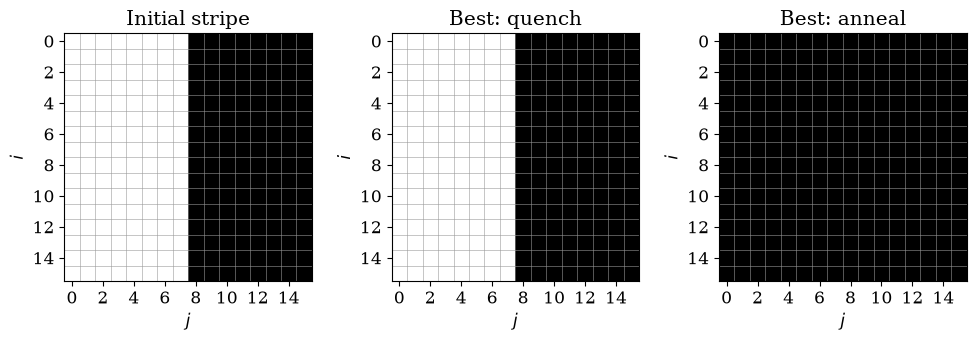

In [36]:
plt.figure(figsize=(10, 3.3))
for k, (state, title) in enumerate(zip([stripe, *example_best], ["Initial stripe", "Best: quench", "Best: anneal"])):
    plt.subplot(1, 3, k + 1)
    show_spins(state)
    plt.title(title)
plt.tight_layout()
plt.show()

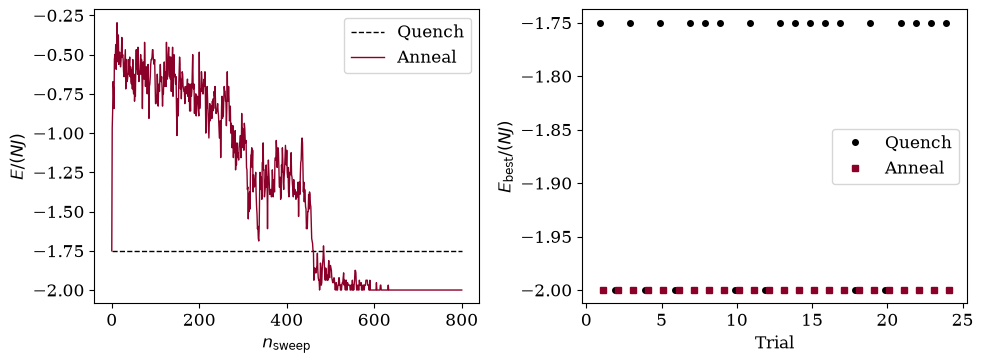

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for p, (name, style, color) in enumerate(zip(protocol_names, ["--", "-"], ["black", "#8B0029"])):
    trace = example_traces[p] / L**2
    axes[0].plot(trace, style, color=color, linewidth=1, label=name)
    axes[1].plot(np.arange(1, n_trials + 1) + (p - 0.5) * 0.25, best_energies[:, p] / L**2,
                 "o" if p == 0 else "s", color=color, label=name, markersize=4)
axes[0].set(xlabel=r"$n_{\mathrm{sweep}}$", ylabel=r"$E/(NJ)$")
axes[1].set(xlabel="Trial", ylabel=r"$E_{\mathrm{best}}/(NJ)$")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

In [38]:
ground_energy = -2 * L * L
for start_type, rows in [("Stripe", slice(0, None, 2)), ("Random", slice(1, None, 2))]:
    for p, name in enumerate(protocol_names):
        best = best_energies[rows, p]
        success = np.count_nonzero(best == ground_energy)
        print(f"{start_type:6s} / {name:6s}: ground state {success}/{len(best)}, "
              f"mean best E/N={best.mean()/L**2:.4f}, "
              f"mean final E/N={final_energies[rows, p].mean()/L**2:.4f}")

Stripe / Quench: ground state 0/12, mean best E/N=-1.7500, mean final E/N=-1.7500
Stripe / Anneal: ground state 12/12, mean best E/N=-2.0000, mean final E/N=-2.0000
Random / Quench: ground state 7/12, mean best E/N=-1.8958, mean final E/N=-1.8958
Random / Anneal: ground state 12/12, mean best E/N=-2.0000, mean final E/N=-2.0000


**Compare:** which protocol crosses the barrier from the stripe state?
Which spends some of its fixed computation budget at higher temperatures?
Keep cooling samples separate from the equilibrium temperature scan.
This uniform ferromagnet has a known ground state. Harder optimization examples include
frustrated spin systems and route planning.

## Practice

1. Cache the acceptance probabilities for positive local energy changes. Measure the effect.
2. Change the cooling schedule while keeping the attempt budget fixed.
3. Increase size or sample count and check whether the Binder crossing moves.
4. Explain why faster code does not automatically produce more independent samples per sweep.

## References

- [Numba: performance tips](https://numba.readthedocs.io/en/stable/user/performance-tips.html)
- [Clark: simulating the Ising model](https://courses.physics.illinois.edu/PHYS446/sp2023/Ising/IsingModel.html)
- [Troyer: computational physics, sections 7.4–7.5](https://archiv.ifb.ethz.ch/education/IntroductionComPhys/2009HS/ScriptTroyer.pdf)
- [Kirkpatrick, Gelatt, and Vecchi: Optimization by Simulated Annealing (1983)](https://doi.org/10.1126/science.220.4598.671)